In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_DIR = Path("../Dataset/Raw")
PROCESSED_DIR = Path("../Dataset/Processed")

PROCESSED_DIR.mkdir(exist_ok=True)

In [2]:
meta_path = RAW_DIR / "games_detailed_info.csv"
df_meta = pd.read_csv(meta_path)

print(df_meta.shape)
df_meta.head()

(21631, 56)


C:\Users\felix\AppData\Local\Temp\ipykernel_4764\448021550.py:2: DtypeWarning: Columns (29,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(meta_path)


,Unnamed: 0,type,id,thumbnail,image,primary,alternate,description,yearpublished,minplayers,...,War Game Rank,Customizable Rank,Children's Game Rank,RPG Item Rank,Accessory Rank,Video Game Rank,Amiga Rank,Commodore 64 Rank,Arcade Rank,Atari ST Rank
0,0,boardgame,30549,https://cf.geekdo-images.com/S3ybV1LAp-8SnHIXL...,https://cf.geekdo-images.com/S3ybV1LAp-8SnHIXL...,Pandemic,"['EPIZOotic', 'Pandemia', 'Pandemia 10 Anivers...","In Pandemic, several virulent diseases have br...",2008,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,boardgame,822,https://cf.geekdo-images.com/okM0dq_bEXnbyQTOv...,https://cf.geekdo-images.com/okM0dq_bEXnbyQTOv...,Carcassonne,"['Carcassonne Jubilee Edition', 'Carcassonne: ...",Carcassonne is a tile-placement game in which ...,2000,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,boardgame,13,https://cf.geekdo-images.com/W3Bsga_uLP9kO91gZ...,https://cf.geekdo-images.com/W3Bsga_uLP9kO91gZ...,Catan,"['CATAN', 'Catan (Колонизаторы)', 'Catan telep...","In CATAN (formerly The Settlers of Catan), pla...",1995,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,boardgame,68448,https://cf.geekdo-images.com/RvFVTEpnbb4NM7k0I...,https://cf.geekdo-images.com/RvFVTEpnbb4NM7k0I...,7 Wonders,"['7 csoda', '7 Cudów Świata', '7 divů světa', ...",You are the leader of one of the 7 great citie...,2010,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,boardgame,36218,https://cf.geekdo-images.com/j6iQpZ4XkemZP07HN...,https://cf.geekdo-images.com/j6iQpZ4XkemZP07HN...,Dominion,"['Dominion: Basisspiel', 'Dominion: In naam va...","&quot;You are a monarch, like your parents bef...",2008,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
meta_cols = [
    "id", "primary", "yearpublished", "minplayers", "maxplayers", "minplaytime",
    "maxplaytime", "minage", "Board Game Rank", "average", "bayesaverage", 
    "usersrated", "averageweight", "boardgamecategory", 
    "boardgamemechanic", "description"
]

df_meta_clean = df_meta[meta_cols].drop_duplicates(subset="id")

df_meta_clean = df_meta_clean.rename(columns={
    "primary": "name",
    "Board Game Rank": "rank",
    "boardgamecategory": "category",
    "boardgamemechanic": "mechanic"
})

df_meta_clean.head()

,id,name,yearpublished,minplayers,maxplayers,minplaytime,maxplaytime,minage,rank,average,bayesaverage,usersrated,averageweight,category,mechanic,description
0,30549,Pandemic,2008,2,4,45,45,8,106,7.58896,7.48669,109006,2.4063,['Medical'],"['Action Points', 'Cooperative Game', 'Hand Ma...","In Pandemic, several virulent diseases have br..."
1,822,Carcassonne,2000,2,5,30,45,7,191,7.41837,7.30857,108776,1.9057,"['City Building', 'Medieval', 'Territory Build...","['Area Majority / Influence', 'Map Addition', ...",Carcassonne is a tile-placement game in which ...
2,13,Catan,1995,3,4,60,120,10,429,7.13598,6.96965,108064,2.3130,"['Economic', 'Negotiation']","['Dice Rolling', 'Hexagon Grid', 'Income', 'Mo...","In CATAN (formerly The Settlers of Catan), pla..."
3,68448,7 Wonders,2010,2,7,30,30,10,73,7.73515,7.63355,90021,2.3264,"['Ancient', 'Card Game', 'City Building', 'Civ...","['Drafting', 'Hand Management', 'Set Collectio...",You are the leader of one of the 7 great citie...
4,36218,Dominion,2008,2,4,30,30,13,104,7.61000,7.49912,81582,2.3542,"['Card Game', 'Medieval']","['Deck, Bag, and Pool Building', 'Delayed Purc...","&quot;You are a monarch, like your parents bef..."


In [4]:
reviews_path = RAW_DIR / "large_bgg-26m-reviews.csv"

df_reviews = pd.read_csv(
    reviews_path,
    usecols=["user", "ID", "rating", "comment", "name"],
    nrows=500000
)

print(df_reviews.shape)
df_reviews.head()

(500000, 5)


,user,rating,comment,ID,name
0,sidehacker,10.0,NaN,13,CATAN
1,Varthlokkur,10.0,NaN,13,CATAN
2,dougthonus,10.0,"Currently, this sits on my list as my favorite...",13,CATAN
3,cypar7,10.0,"I know it says how many plays, but many, many ...",13,CATAN
4,ssmooth,10.0,NaN,13,CATAN


In [5]:
df_reviews = df_reviews.dropna(subset=["comment"])
df_reviews["comment"] = df_reviews["comment"].astype(str)

df_reviews_clean = df_reviews[df_reviews["comment"].str.strip() != ""]
df_reviews_clean.head()

,user,rating,comment,ID,name
2,dougthonus,10.0,"Currently, this sits on my list as my favorite...",13,CATAN
3,cypar7,10.0,"I know it says how many plays, but many, many ...",13,CATAN
7,hreimer,10.0,i will never tire of this game.. Awesome,13,CATAN
11,daredevil,10.0,This is probably the best game I ever played. ...,13,CATAN
16,hurkle,10.0,Fantastic game. Got me hooked on games all ove...,13,CATAN


In [6]:
df_merged = df_reviews_clean.merge(
    df_meta_clean,
    left_on="ID",
    right_on="id",
    how="left"
)

df_merged.head()

,user,rating,comment,ID,name_x,id,name_y,yearpublished,minplayers,maxplayers,...,maxplaytime,minage,rank,average,bayesaverage,usersrated,averageweight,category,mechanic,description
0,dougthonus,10.0,"Currently, this sits on my list as my favorite...",13,CATAN,13,Catan,1995,3,4,...,120,10,429,7.13598,6.96965,108064,2.313,"['Economic', 'Negotiation']","['Dice Rolling', 'Hexagon Grid', 'Income', 'Mo...","In CATAN (formerly The Settlers of Catan), pla..."
1,cypar7,10.0,"I know it says how many plays, but many, many ...",13,CATAN,13,Catan,1995,3,4,...,120,10,429,7.13598,6.96965,108064,2.313,"['Economic', 'Negotiation']","['Dice Rolling', 'Hexagon Grid', 'Income', 'Mo...","In CATAN (formerly The Settlers of Catan), pla..."
2,hreimer,10.0,i will never tire of this game.. Awesome,13,CATAN,13,Catan,1995,3,4,...,120,10,429,7.13598,6.96965,108064,2.313,"['Economic', 'Negotiation']","['Dice Rolling', 'Hexagon Grid', 'Income', 'Mo...","In CATAN (formerly The Settlers of Catan), pla..."
3,daredevil,10.0,This is probably the best game I ever played. ...,13,CATAN,13,Catan,1995,3,4,...,120,10,429,7.13598,6.96965,108064,2.313,"['Economic', 'Negotiation']","['Dice Rolling', 'Hexagon Grid', 'Income', 'Mo...","In CATAN (formerly The Settlers of Catan), pla..."
4,hurkle,10.0,Fantastic game. Got me hooked on games all ove...,13,CATAN,13,Catan,1995,3,4,...,120,10,429,7.13598,6.96965,108064,2.313,"['Economic', 'Negotiation']","['Dice Rolling', 'Hexagon Grid', 'Income', 'Mo...","In CATAN (formerly The Settlers of Catan), pla..."


In [7]:
output_path = PROCESSED_DIR / "merged_clean_sample.csv"
df_merged.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: ..\Dataset\Processed\merged_clean_sample.csv


In [8]:
from transformers import pipeline
import pandas as pd
from tqdm import tqdm

sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

tqdm.pandas(desc="Analyzing Sentiment")

def analyze_sentiment_safe(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {"label": "NEUTRAL", "score": 0.0}
    try:
        result = sentiment_analyzer(text[:1000])[0]
        return result
    except Exception:
        return {"label": "NEUTRAL", "score": 0.0}

df_reviews_clean["sentiment_result"] = df_reviews_clean["comment"].progress_apply(analyze_sentiment_safe)

df_reviews_clean["sentiment_label"] = df_reviews_clean["sentiment_result"].apply(lambda x: x["label"])
df_reviews_clean["sentiment_score"] = df_reviews_clean["sentiment_result"].apply(lambda x: x["score"])

df_reviews_clean["sentiment_label"].value_counts()


Device set to use cpu
Analyzing Sentiment: 100%|██████████| 71200/71200 [1:01:24<00:00, 19.32it/s]
C:\Users\felix\AppData\Local\Temp\ipykernel_4764\2387364593.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reviews_clean["sentiment_result"] = df_reviews_clean["comment"].progress_apply(analyze_sentiment_safe)
C:\Users\felix\AppData\Local\Temp\ipykernel_4764\2387364593.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reviews_clean["sentiment_label"] = df_reviews_clean["sentiment_result"].apply(

sentiment_label
POSITIVE    58560
NEGATIVE    12640
Name: count, dtype: int64

In [9]:
output_path = "../Dataset/Processed/reviews_with_sentiment.csv"
df_reviews_clean.to_csv(output_path, index=False, encoding="utf-8")
print(f"✅ Sentiment-labeled reviews saved to: {output_path}")
print("Shape:", df_reviews_clean.shape)

✅ Sentiment-labeled reviews saved to: ../Dataset/Processed/reviews_with_sentiment.csv
Shape: (71200, 8)


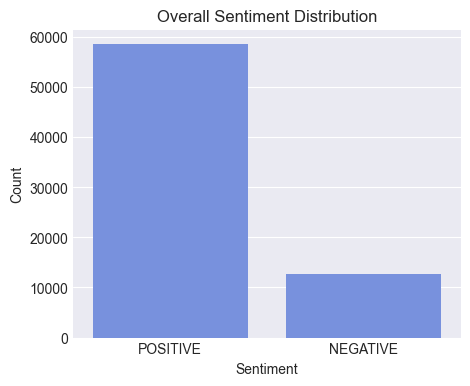

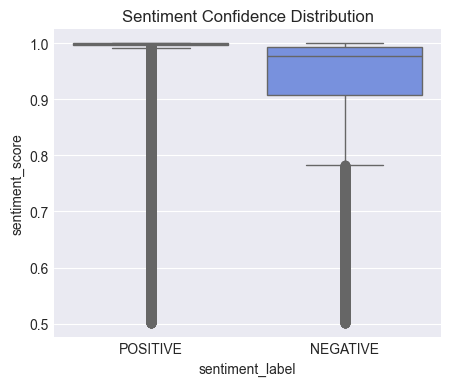

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("coolwarm")

sentiment_counts = df_reviews_clean["sentiment_label"].value_counts()

plt.figure(figsize=(5,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(x="sentiment_label", y="sentiment_score", data=df_reviews_clean)
plt.title("Sentiment Confidence Distribution")
plt.show()

In [11]:
print("Columns in df_meta_clean:")
print(df_meta_clean.columns.tolist())

Columns in df_meta_clean:
['id', 'name', 'yearpublished', 'minplayers', 'maxplayers', 'minplaytime', 'maxplaytime', 'minage', 'rank', 'average', 'bayesaverage', 'usersrated', 'averageweight', 'category', 'mechanic', 'description']


In [12]:
df_sent_meta = df_reviews_clean.merge(
    df_meta_clean[["id", "name", "average", "usersrated"]],
    left_on="ID", right_on="id", how="left",
    suffixes=("_review", "_meta")
)

print("✅ After merge:", df_sent_meta.shape)
print("Columns:", df_sent_meta.columns.tolist()[:15])

sent_summary = (
    df_sent_meta.groupby(["id", "name_meta"], dropna=False)
    .agg(
        avg_sentiment_score=("sentiment_score", "mean"),
        positive_rate=("sentiment_label", lambda x: (x == "POSITIVE").mean()),
        average_rating=("average", "mean"),
        review_count=("ID", "count")
    )
    .reset_index()
)

sent_summary = sent_summary.rename(columns={"name_meta": "name"})

print("✅ Sentiment summary created:", sent_summary.shape)
display(sent_summary.head(10))

✅ After merge: (71200, 12)
Columns: ['user', 'rating', 'comment', 'ID', 'name_review', 'sentiment_result', 'sentiment_label', 'sentiment_score', 'id', 'name_meta', 'average', 'usersrated']
✅ Sentiment summary created: (20, 6)


,id,name,avg_sentiment_score,positive_rate,average_rating,review_count
0,13,Catan,0.972738,0.816905,7.13598,4342
1,822,Carcassonne,0.973266,0.822596,7.41837,4098
2,3076,Puerto Rico,0.971305,0.806823,7.96662,4514
3,9209,Ticket to Ride,0.975241,0.847043,7.41291,4498
4,14996,Ticket to Ride: Europe,0.967319,0.821231,7.54362,3429
5,30549,Pandemic,0.972144,0.853581,7.58896,3449
6,31260,Agricola,0.966084,0.775623,7.92581,4332
7,36218,Dominion,0.969046,0.806146,7.61000,3905
8,40692,Small World,0.968124,0.822001,7.24600,3309
9,68448,7 Wonders,0.971764,0.846175,7.73515,3621


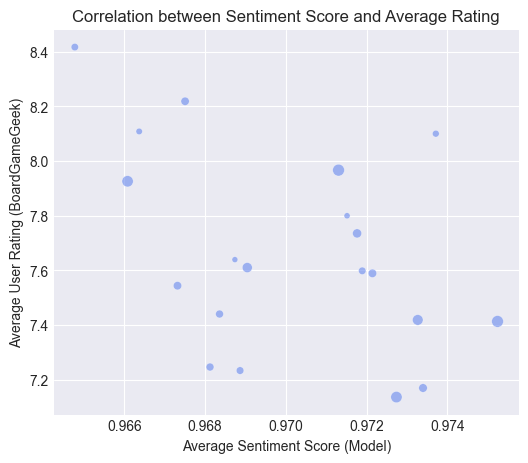

📈 Correlation between sentiment score and rating: -0.445


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=sent_summary,
    x="avg_sentiment_score",
    y="average_rating",
    size="review_count",
    alpha=0.6
)
plt.title("Correlation between Sentiment Score and Average Rating")
plt.xlabel("Average Sentiment Score (Model)")
plt.ylabel("Average User Rating (BoardGameGeek)")
plt.legend([], [], frameon=False)
plt.show()

corr_value = sent_summary[["avg_sentiment_score", "average_rating"]].corr().iloc[0, 1]
print(f"📈 Correlation between sentiment score and rating: {corr_value:.3f}")